# ZQE-GLLVM: L-BFGS encoder + deterministic centering with fixed (Z̃, U) draws

Full pipeline:
1. Fix noise draws **Z̃** ∈ ℝ^{M×q} and **U** ∈ [0,1]^{M×p} once at init.
2. At every θ = (W, b): impute ẑᵢ = argmax_z log p(yᵢ|z,θ) + log p(z) via **L-BFGS with `zero_grad`** (no gradient flows into θ through ẑ).
3. Compute centering draws ỹₘ(θ) = Poisson_icdf(U, exp(Z̃ W^T + b)) — piecewise constant in θ, no resampling ever.
4. ZQE objective: L(θ) = (1/N) Σᵢ yᵢ^T (Wẑᵢ+b) − (1/M) Σₘ ỹₘ^T (Wz̃ₘ+b), minimised via outer L-BFGS over (W, b).


## 1. Imports & Configuration

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import poisson as sp_poisson

# ── Global hyperparameters ───────────────────────────────────────────────────
N      = 200      # number of observations
P      = 10       # response dimension  (number of features / GLMs)
Q      = 1        # latent dimension
M      = 100      # number of fixed simulation draws for ZQE centering
RIDGE  = 1.0      # N(0,I) prior precision on both Z and W
ENC_ITER = 50     # L-BFGS steps for encoder (imputation)
DEC_ITER = 100     # L-BFGS steps for outer decoder solve
DATA_SEED = 42
DRAW_SEED = 7     # fixed seed for Z̃, U — never changes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device}  N={N}  P={P}  Q={Q}  M={M}")


device=cuda  N=200  P=10  Q=1  M=100


## 2. Synthetic Data Generation

In [2]:
def generate_poisson_gllvm(N, P, Q, seed=42, device=device):
    """
    True model: z_i ~ N(0,I_Q),  y_ij ~ Poisson(exp(w_j^T z_i + b_j))

    Returns:
        Y      [N, P]  observed counts
        W_true [P, Q]  true loadings
        b_true [P]     true intercepts
        Z_true [N, Q]  true latents
    """
    g = torch.Generator()  # always CPU generator
    g.manual_seed(seed)
    W_true = torch.randn(P, Q, generator=g) * 0.5
    b_true = torch.randn(P,    generator=g) * 0.3
    Z_true = torch.randn(N, Q, generator=g)

    with torch.no_grad():
        eta = Z_true @ W_true.T + b_true          # [N, P]
        lam = eta.clamp(-6, 6).exp()
        Y   = torch.poisson(lam)

    return Y.to(device), W_true.to(device), b_true.to(device), Z_true.to(device)


Y, W_true, b_true, Z_true = generate_poisson_gllvm(N, P, Q, seed=DATA_SEED)
print(f"Y shape={Y.shape}  mean={Y.mean():.2f}  max={Y.max():.0f}")
print(f"W_true range=[{W_true.min():.2f}, {W_true.max():.2f}]")


Y shape=torch.Size([200, 10])  mean=1.24  max=125
W_true range=[-0.56, 1.10]


## 3. Fixed (Z̃, U) Draws — drawn once, never resampled

Z̃ ∈ ℝ^{M×Q} and U ∈ [0,1]^{M×P} are frozen at init.  
ỹₘ(θ) = Poisson_icdf(U[m,:], exp(Z̃[m,:] @ W^T + b)) computed inside `no_grad` each closure call.


In [3]:
def get_fixed_draws(M, Q, P, seed=DRAW_SEED, device=device):
    """
    Draw Z_sim [M, Q] ~ N(0,I) and U_sim [M, P] ~ Uniform(0,1) once.
    These are frozen forever — no gradient, no resampling.
    Generator is always CPU; tensors moved to device after.
    """
    g = torch.Generator()  # CPU generator — works on any device target
    g.manual_seed(seed)
    Z_sim = torch.randn(M, Q, generator=g).to(device)
    U_sim = torch.rand( M, P, generator=g).clamp(1e-6, 1 - 1e-6).to(device)
    return Z_sim, U_sim


def poisson_icdf(U_np, lam_np):
    """
    Vectorised Poisson inverse-CDF using scipy.
    U_np, lam_np: numpy arrays of shape [M, P], same shape.
    Returns integer counts [M, P] as a torch tensor.
    """
    counts = sp_poisson.ppf(U_np, lam_np).astype(np.float32)
    return torch.from_numpy(counts)


def sim_centering_counts(Z_sim, U_sim, W, b):
    """
    Compute ỹₘ(θ) = Poisson_icdf(U_sim, exp(Z_sim @ W^T + b))   [M, P]
    Everything inside no_grad — ỹ is piecewise constant in θ,
    the integers enter the ZQE objective as detached constants.
    """
    with torch.no_grad():
        eta_sim = (Z_sim @ W.detach().T + b.detach()).clamp(-60, 60)  # [M, P]
        lam_sim = eta_sim.exp().cpu().numpy()
        U_np    = U_sim.cpu().numpy()
        Y_sim   = poisson_icdf(U_np, lam_sim).to(W.device)  # [M, P]
    return Y_sim


# ── Freeze draws ─────────────────────────────────────────────────────────────
Z_sim, U_sim = get_fixed_draws(M, Q, P, seed=DRAW_SEED)
print(f"Z_sim {Z_sim.shape}  U_sim {U_sim.shape}")

# Quick sanity: centering counts with true params should be Poisson-distributed
Y_sim_check = sim_centering_counts(Z_sim, U_sim, W_true, b_true)
print(f"Y_sim range=[{Y_sim_check.min():.0f}, {Y_sim_check.max():.0f}]  mean={Y_sim_check.mean():.2f}")


Z_sim torch.Size([100, 1])  U_sim torch.Size([100, 10])
Y_sim range=[0, 13]  mean=1.18
Y_sim range=[0, 13]  mean=1.18


## 4. Encoder: Impute Z via L-BFGS inside `zero_grad`

For each observation i, solve:  
&nbsp;&nbsp;&nbsp;&nbsp;ẑᵢ = argmin_z  Σⱼ [exp(wⱼ^T z + bⱼ) − yᵢⱼ (wⱼ^T z + bⱼ)] + ½‖z‖²

Vectorised over all N observations simultaneously (B = Z^T, X = W).  
W and b are detached — **no gradient flows back through the encoder**.


In [4]:
def impute_Z_lbfgs(W, b, Y, Z_init=None, ridge=RIDGE, max_iter=ENC_ITER):
    """
    MAP imputation of Z given fixed (W, b) and observed counts Y.

    All computation inside torch.no_grad() — zero gradient flows into (W, b).

    Parameters
    ----------
    W      : [P, Q]  loadings  (will be detached)
    b      : [P]     intercepts (will be detached)
    Y      : [N, P]  observed counts
    Z_init : [N, Q]  warm start (optional; falls back to log1p Gaussian approx)
    ridge  : float   N(0,I) prior precision on Z

    Returns
    -------
    Z_hat : [N, Q]  MAP estimates, detached, no grad
    """
    W_d = W.detach()
    b_d = b.detach()

    # ── warm start: fast Gaussian log1p approximation ─────────────────────────
    if Z_init is None:
        log1p_Y = torch.log1p(Y)                     # [N, P]
        # solve W_d^T Z^T ≈ (log1p_Y - b_d)^T  →  Z [N, Q]
        # i.e.  Z = (log1p_Y - b_d) @ W_d @ (W_d^T W_d)^{-1}
        WtW = W_d.T @ W_d + ridge * torch.eye(Q, device=W.device)
        rhs = (log1p_Y - b_d) @ W_d                 # [N, Q]
        Z_init = torch.linalg.solve(WtW.T, rhs.T).T  # [N, Q]

    with torch.no_grad():
        Z = torch.nn.Parameter(Z_init.clone())
        opt = torch.optim.LBFGS([Z], max_iter=max_iter,
                                 history_size=10,
                                 line_search_fn="strong_wolfe")

        def closure():
            opt.zero_grad()
            eta  = (Z @ W_d.T + b_d).clamp(-60, 60)   # [N, P]
            nll  = (eta.exp() - Y * eta).sum()
            nll  = nll + 0.5 * ridge * (Z ** 2).sum()
            nll.backward()
            return nll

        opt.step(closure)
        return Z.detach()


# ── quick sanity check ────────────────────────────────────────────────────────
Z_hat_test = impute_Z_lbfgs(W_true, b_true, Y)
corr_z = torch.corrcoef(torch.stack([Z_true.flatten(), Z_hat_test.flatten()]))[0, 1].item()
print(f"Encoder sanity (true W,b) — corr(Z_true, Z_hat) = {corr_z:.4f}")


Encoder sanity (true W,b) — corr(Z_true, Z_hat) = 0.8606


## 5. ZQE Objective

$$\mathcal{L}_{\text{ZQE}}(W, b) = \underbrace{\frac{1}{N}\sum_{i=1}^N y_i^\top (W\hat{z}_i + b)}_{\text{real cross-term}} - \underbrace{\frac{1}{M}\sum_{m=1}^M \tilde{y}_m(\theta)^\top (W\tilde{z}_m + b)}_{\text{centering: fixed } \tilde{Z},\tilde{U}}$$

Gradient flows only through the linear terms $W\hat{z}_i + b$ and $W\tilde{z}_m + b$, where $\hat{z}_i$, $\tilde{z}_m$, and $\tilde{y}_m$ are all **detached**.


In [5]:
from scipy.linalg import orthogonal_procrustes

def procrustes_align(W_true, W_est):
    """
    Orthogonal Procrustes alignment: find R (Q×Q orthogonal) minimising
        ‖W_est @ R − W_true‖_F   (pure rotation, NO mean-centering)
    Returns W_est_aligned [P, Q] as a torch tensor.
    """
    A = W_true.detach().cpu().numpy()   # [P, Q]  (target)
    B = W_est.detach().cpu().numpy()    # [P, Q]  (to rotate)
    if A.shape[1] == 1:
        sign = float(np.sign((B * A).sum()))
        R = np.array([[sign]])
    else:
        R, _ = orthogonal_procrustes(B, A)   # solves B R ≈ A
    B_aligned = B @ R
    return torch.from_numpy(B_aligned.astype(np.float32)).to(W_true.device), R


def zqe_objective(W, b, Y, Z_hat, Z_sim, Y_sim):
    """
    ZQE scalar objective (to minimise = centering − real).

    All inputs except W, b are detached — gradient flows only through
    the linear predictors W @ z + b evaluated at fixed z.
    """
    # Real cross-term: (1/N) Σ yᵢ^T (W ẑᵢ + b)
    eta_real  = Z_hat.detach() @ W.T + b              # [N, P]
    real_term = (Y.detach() * eta_real).sum() / Y.shape[0]

    # Centering term: (1/M) Σ ỹₘ^T (W z̃ₘ + b)
    eta_sim   = Z_sim.detach() @ W.T + b              # [M, P]
    cent_term = (Y_sim.detach() * eta_sim).sum() / Z_sim.shape[0]

    # Maximise real − centering  →  minimise centering − real
    return cent_term - real_term


# ── Sanity: gradient at true params should be ≈ 0 ────────────────────────────
W_t = W_true.clone().requires_grad_(True)
b_t = b_true.clone().requires_grad_(True)
Z_hat_t  = impute_Z_lbfgs(W_t, b_t, Y)
Y_sim_t  = sim_centering_counts(Z_sim, U_sim, W_t, b_t)
loss_t   = zqe_objective(W_t, b_t, Y, Z_hat_t, Z_sim, Y_sim_t)
loss_t.backward()
print(f"ZQE loss at true params: {loss_t.item():.4f}")
print(f"‖∇W‖ = {W_t.grad.norm():.4f}  (should be small at true θ)")


ZQE loss at true params: -4.3185
‖∇W‖ = 3.7855  (should be small at true θ)


## 6. Full ZQE L-BFGS Solver

Single L-BFGS pass over (W, b). Each closure call:
1. Imputes Z_hat via inner L-BFGS encoder (inside `no_grad`)
2. Computes centering counts ỹ via Poisson icdf (inside `no_grad`)
3. Evaluates ZQE loss and calls `.backward()` — gradients flow only through linear terms in (W, b)


In [6]:
def fit_zqe_lbfgs(Y, Z_sim, U_sim, Q,
                  ridge=RIDGE, dec_iter=DEC_ITER, enc_iter=ENC_ITER,
                  W_true=None, device=device):
    """
    Fit Poisson GLLVM via ZQE with deterministic fixed-seed centering.

    Single L-BFGS pass over (W, b) — one optimizer, one opt.step call.
    The closure (called once per L-BFGS iteration + line-search probes):
      1. Imputes Z_hat via inner L-BFGS at current (W, b)
      2. Computes Y_sim via Poisson icdf at current (W, b) with fixed U_sim
      3. Evaluates ZQE loss and backprops through (W, b) only
    """
    N, P = Y.shape

    # ── Initialise (W, b) from SVD of log1p(Y) ───────────────────────────────
    log1pY   = torch.log1p(Y)
    log1pY_c = log1pY - log1pY.mean(0)
    _, S_svd, Vh_svd = torch.linalg.svd(log1pY_c, full_matrices=False)
    W = torch.nn.Parameter(
        (Vh_svd[:Q].T * (S_svd[:Q] / N**0.5)).float().contiguous().to(device))
    b = torch.nn.Parameter(log1pY.mean(0).contiguous().to(device))

    opt = torch.optim.LBFGS([W, b], max_iter=dec_iter,
                              history_size=20,
                              line_search_fn="strong_wolfe")

    n_calls = [0]
    t0 = time.time()

    def closure():
        n_calls[0] += 1
        opt.zero_grad()
        Z_hat = impute_Z_lbfgs(W, b, Y, Z_init=None, ridge=ridge, max_iter=enc_iter)
        Y_sim = sim_centering_counts(Z_sim, U_sim, W, b)
        loss  = zqe_objective(W, b, Y, Z_hat, Z_sim, Y_sim)
        loss.backward()
        return loss

    opt.step(closure)

    W_est = W.detach()
    b_est = b.detach()
    print(f"Done: {n_calls[0]} closure calls in {time.time()-t0:.1f}s")

    if W_true is not None:
        W_al, _ = procrustes_align(W_true, W_est)
        r = torch.corrcoef(torch.stack([W_true.flatten(), W_al.flatten()]))[0, 1].item()
        print(f"r(W, Procrustes) = {r:.4f}")

    return W_est, b_est


# ── Run fit ───────────────────────────────────────────────────────────────────
W_est, b_est = fit_zqe_lbfgs(Y, Z_sim, U_sim, Q, W_true=W_true)


Done: 71 closure calls in 4.0s
r(W, Procrustes) = 0.9310


## 7. Evaluation & Visualisation

W  —  MAE=0.1173   r=0.9310
Z  —  MAE=0.4456   r=0.8459


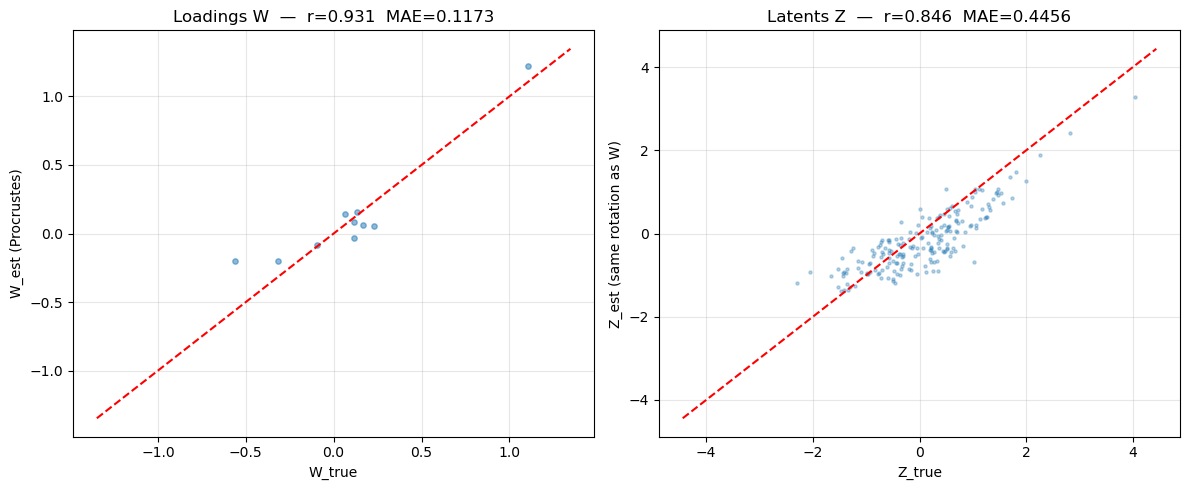

In [7]:
# ── Align W with Procrustes (no centering) ────────────────────────────────────
W_aligned, R_W = procrustes_align(W_true, W_est)
mae_W  = (W_aligned - W_true).abs().mean().item()
corr_W = torch.corrcoef(torch.stack([W_true.flatten(), W_aligned.flatten()]))[0, 1].item()
print(f"W  —  MAE={mae_W:.4f}   r={corr_W:.4f}")

# ── Impute Z then align with same rotation R_W ───────────────────────────────
# Z and W live in the same latent space: apply the same R found for W.
Z_est     = impute_Z_lbfgs(W_est, b_est, Y)
Z_aligned = torch.from_numpy(
    (Z_est.detach().cpu().numpy() @ R_W).astype(np.float32)
).to(Z_true.device)
mae_Z  = (Z_aligned - Z_true).abs().mean().item()
corr_Z = torch.corrcoef(torch.stack([Z_true.flatten(), Z_aligned.flatten()]))[0, 1].item()
print(f"Z  —  MAE={mae_Z:.4f}   r={corr_Z:.4f}")

# ── Scatter plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
wt = W_true.cpu().numpy().flatten()
we = W_aligned.cpu().numpy().flatten()
ax.scatter(wt, we, s=15, alpha=0.5)
lim = max(abs(wt).max(), abs(we).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5)
ax.set_xlabel("W_true"); ax.set_ylabel("W_est (Procrustes)")
ax.set_title(f"Loadings W  —  r={corr_W:.3f}  MAE={mae_W:.4f}")
ax.grid(True, alpha=0.3)

ax = axes[1]
zt = Z_true.cpu().numpy().flatten()
ze = Z_aligned.cpu().numpy().flatten()
ax.scatter(zt, ze, s=5, alpha=0.3)
lim = max(abs(zt).max(), abs(ze).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1.5)
ax.set_xlabel("Z_true"); ax.set_ylabel("Z_est (same rotation as W)")
ax.set_title(f"Latents Z  —  r={corr_Z:.3f}  MAE={mae_Z:.4f}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


∇W — mean=-0.1561  std=0.3325  max|g|=1.1446
∇b — mean=0.2570  std=0.0853  max|g|=0.4200


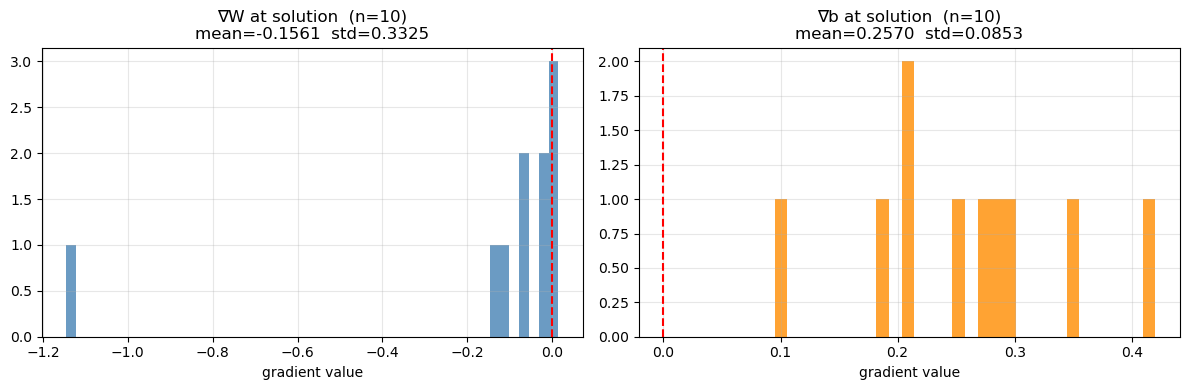

In [8]:

# ── Gradient at the solution ──────────────────────────────────────────────────
W_check = W_est.clone().requires_grad_(True)
b_check = b_est.clone().requires_grad_(True)

Z_hat_check = impute_Z_lbfgs(W_check, b_check, Y, Z_init=None, ridge=RIDGE, max_iter=50)
Y_sim_check2 = sim_centering_counts(Z_sim, U_sim, W_check, b_check)
loss_check = zqe_objective(W_check, b_check, Y, Z_hat_check, Z_sim, Y_sim_check2)
loss_check.backward()

gW = W_check.grad.cpu().numpy().flatten()
gb = b_check.grad.cpu().numpy().flatten()

print(f"∇W — mean={gW.mean():.4f}  std={gW.std():.4f}  max|g|={np.abs(gW).max():.4f}")
print(f"∇b — mean={gb.mean():.4f}  std={gb.std():.4f}  max|g|={np.abs(gb).max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(gW, bins=50, edgecolor='none', alpha=0.8, color='steelblue')
ax.axvline(0, color='r', lw=1.5, ls='--')
ax.set_title(f"∇W at solution  (n={len(gW)})\nmean={gW.mean():.4f}  std={gW.std():.4f}")
ax.set_xlabel("gradient value"); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(gb, bins=30, edgecolor='none', alpha=0.8, color='darkorange')
ax.axvline(0, color='r', lw=1.5, ls='--')
ax.set_title(f"∇b at solution  (n={len(gb)})\nmean={gb.mean():.4f}  std={gb.std():.4f}")
ax.set_xlabel("gradient value"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
